In [1]:
import os
import numpy as np
import glob
import pickle
import matplotlib.pyplot as plt

from tqdm import tqdm

In [4]:
all_lists = {}
for fnet in tqdm(sorted(glob.glob("./data/*.pt"))):
    net = os.path.basename(fnet).split(".")[0]
    with open(fnet, 'rb') as f:
        all_lists[net] = pickle.load(f)[net]
print(f"There are {len(all_lists)} networks in total")

100%|██████████| 483/483 [00:11<00:00, 41.68it/s] 

There are 483 networks in total


In [10]:
sta = {}
siz = {}
for net in tqdm(all_lists.keys()):
    l = []
    s = 0
    for yyyy in all_lists[net].keys():
        for ddd in all_lists[net][yyyy].keys():
            c = all_lists[net][yyyy][ddd]
            l += [i[0] for i in c]
            s += sum([i[1] for i in c])
    sta[net] = list(set(l))
    siz[net] = s

100%|██████████| 483/483 [00:03<00:00, 129.43it/s]


In [11]:
net_sta_count = [[k, len(v)] for k, v in sta.items()]
net_year_count = [[k, all_lists[k].keys()] for k, v in all_lists.items()]
net_size_count = [[k, v / 1024**4] for k, v in siz.items()] # to TBs

Text(0.5, 0, 'Network Code')

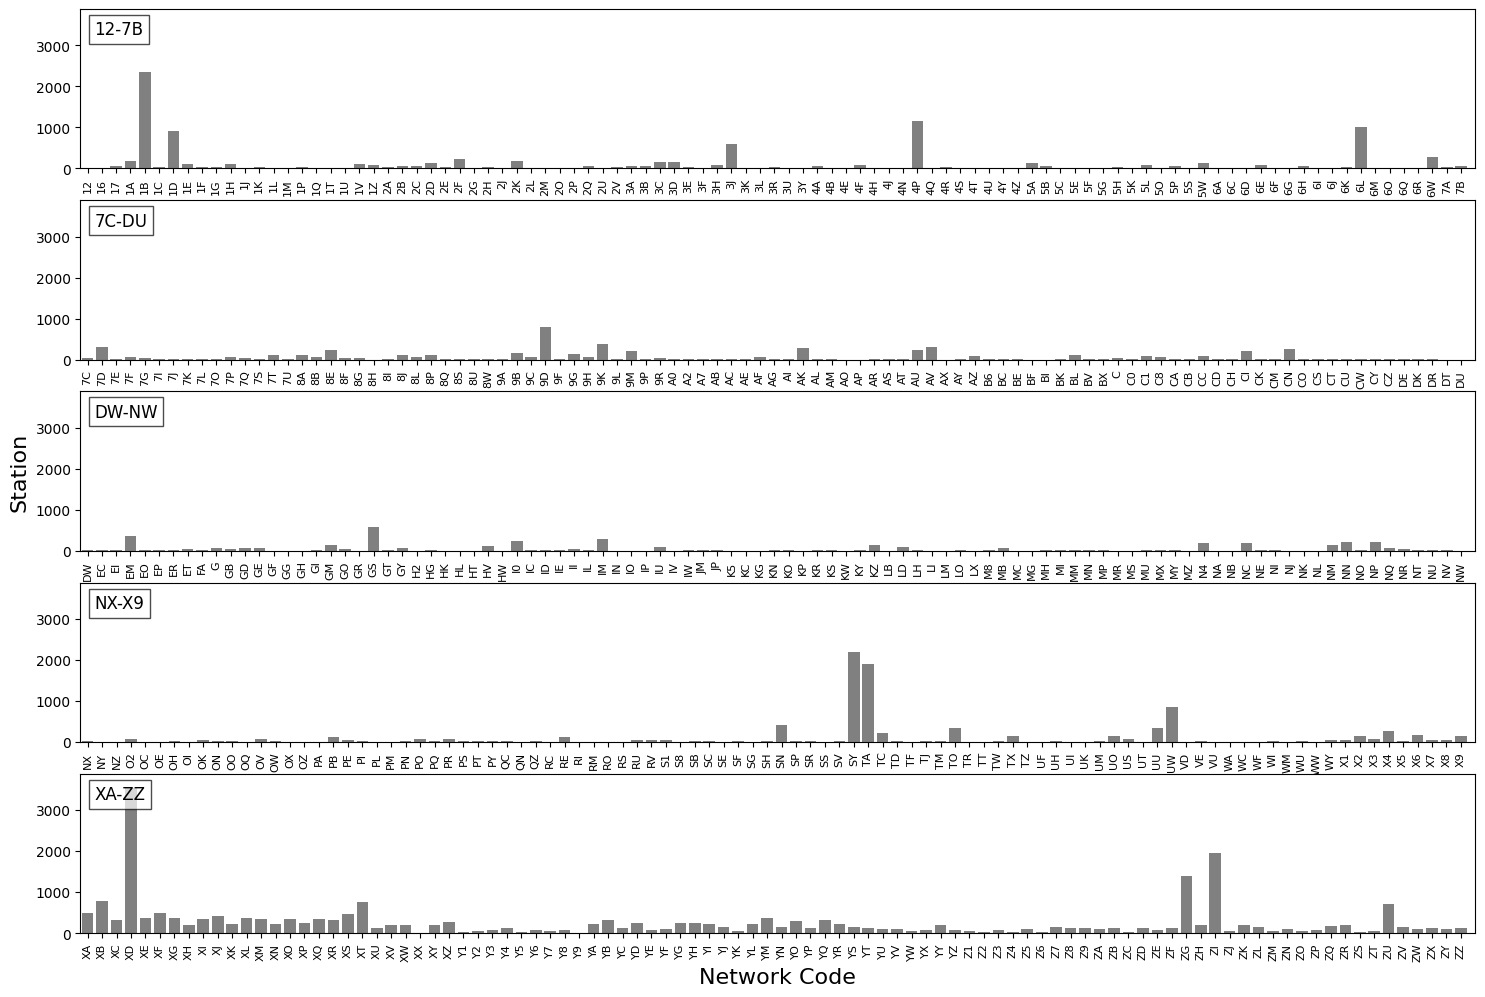

In [12]:
nsub = 5
ps = np.array_split(net_sta_count, nsub)
pmax = max([i[1] for i in net_sta_count]) * 1.1
plt.figure(figsize = (18, 12))
for p in range(nsub):
    plt.subplot(nsub, 1, p+1)
    plt.bar(np.arange(len([i[1] for i in ps[p]])), 
        [float(i[1]) for i in ps[p]], color='gray')
    plt.xticks(np.arange(len([i[1] for i in ps[p]])), [i[0] for i in ps[p]], rotation = 90, fontsize= 8);
    plt.xlim([-0.5, len(ps[p])])
    plt.ylim([0, pmax])
    plt.text(.01, .84, f"{ps[p][0][0]}-{ps[p][-1][0]}", transform=plt.gca().transAxes, 
             bbox=dict(facecolor='white', alpha=0.7), fontsize=12)
    if p == 2:
        plt.ylabel("Station", fontsize = 16)
plt.xlabel("Network Code", fontsize = 16)

Text(0.5, 0, 'Network Code')

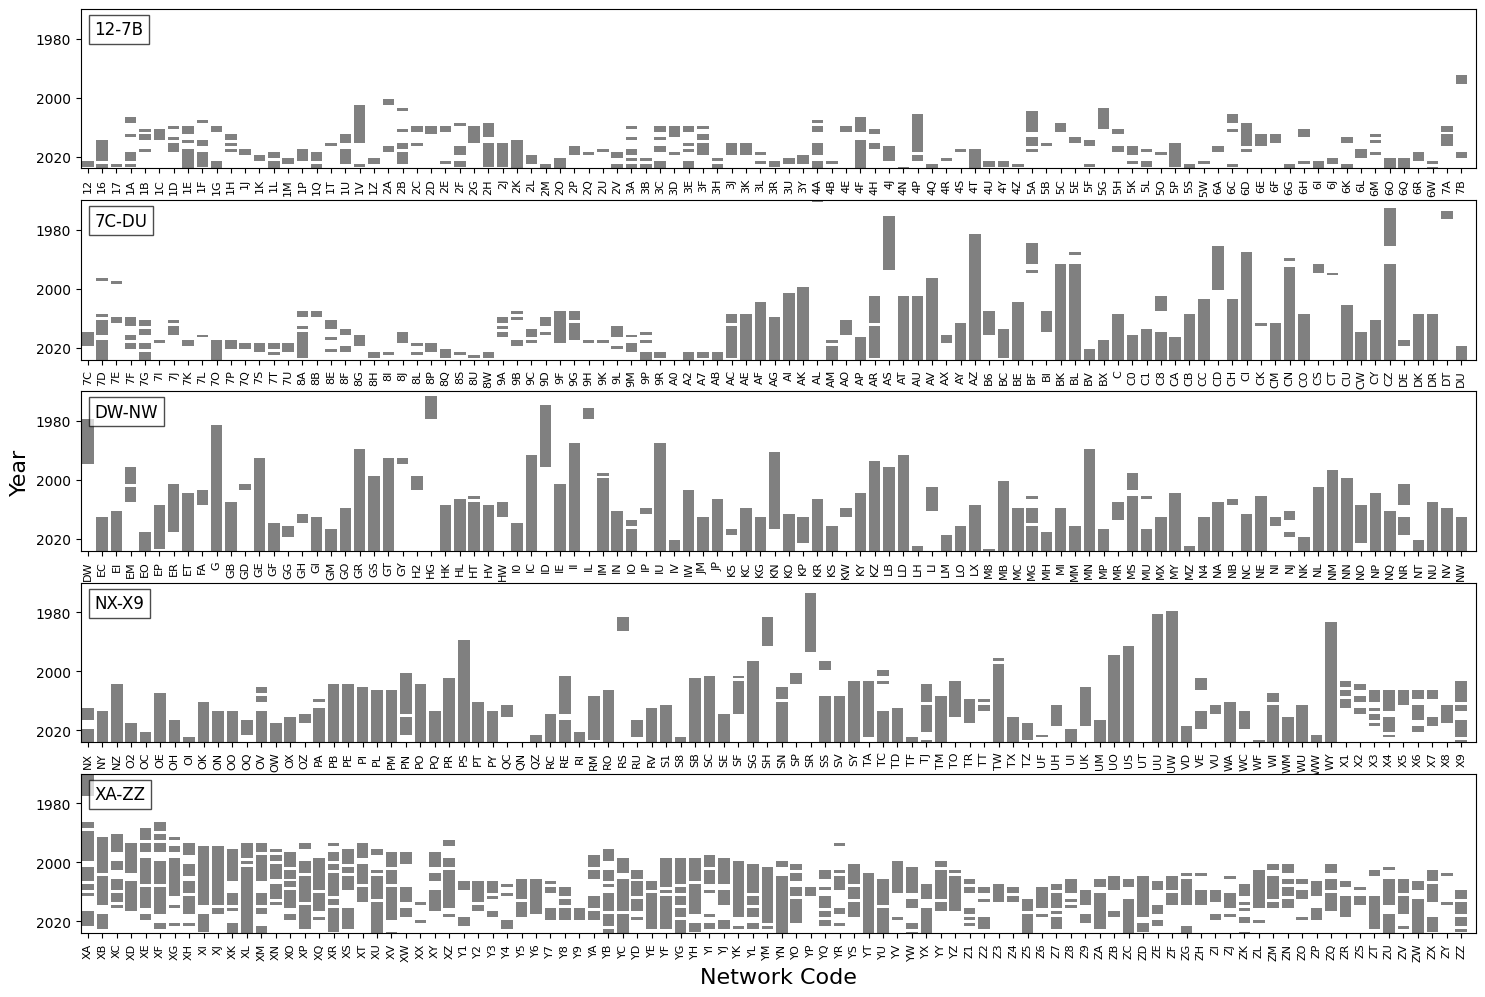

In [13]:
nsub = 5
ps = np.array_split(net_year_count, nsub)
plt.figure(figsize = (18, 12))
for p in range(nsub):
    plt.subplot(nsub, 1, p+1)
    for inet, net in enumerate(ps[p]):
        for y in ps[p][inet][1]:
            plt.bar(inet, 1, bottom = float(y)-0.5, color='gray')
    plt.xticks(np.arange(len([i[1] for i in ps[p]])), [i[0] for i in ps[p]], rotation = 90, fontsize= 8);
    plt.xlim([-0.5, len(ps[p])])
    plt.ylim([2024, 1970])
    plt.text(.01, .84, f"{ps[p][0][0]}-{ps[p][-1][0]}", transform=plt.gca().transAxes, 
             bbox= dict(facecolor = 'white', alpha = 0.7), fontsize = 12)
    if p == 2:
        plt.ylabel("Year", fontsize = 16)
plt.xlabel("Network Code", fontsize = 16)

Text(0.5, 0, 'Network Code')

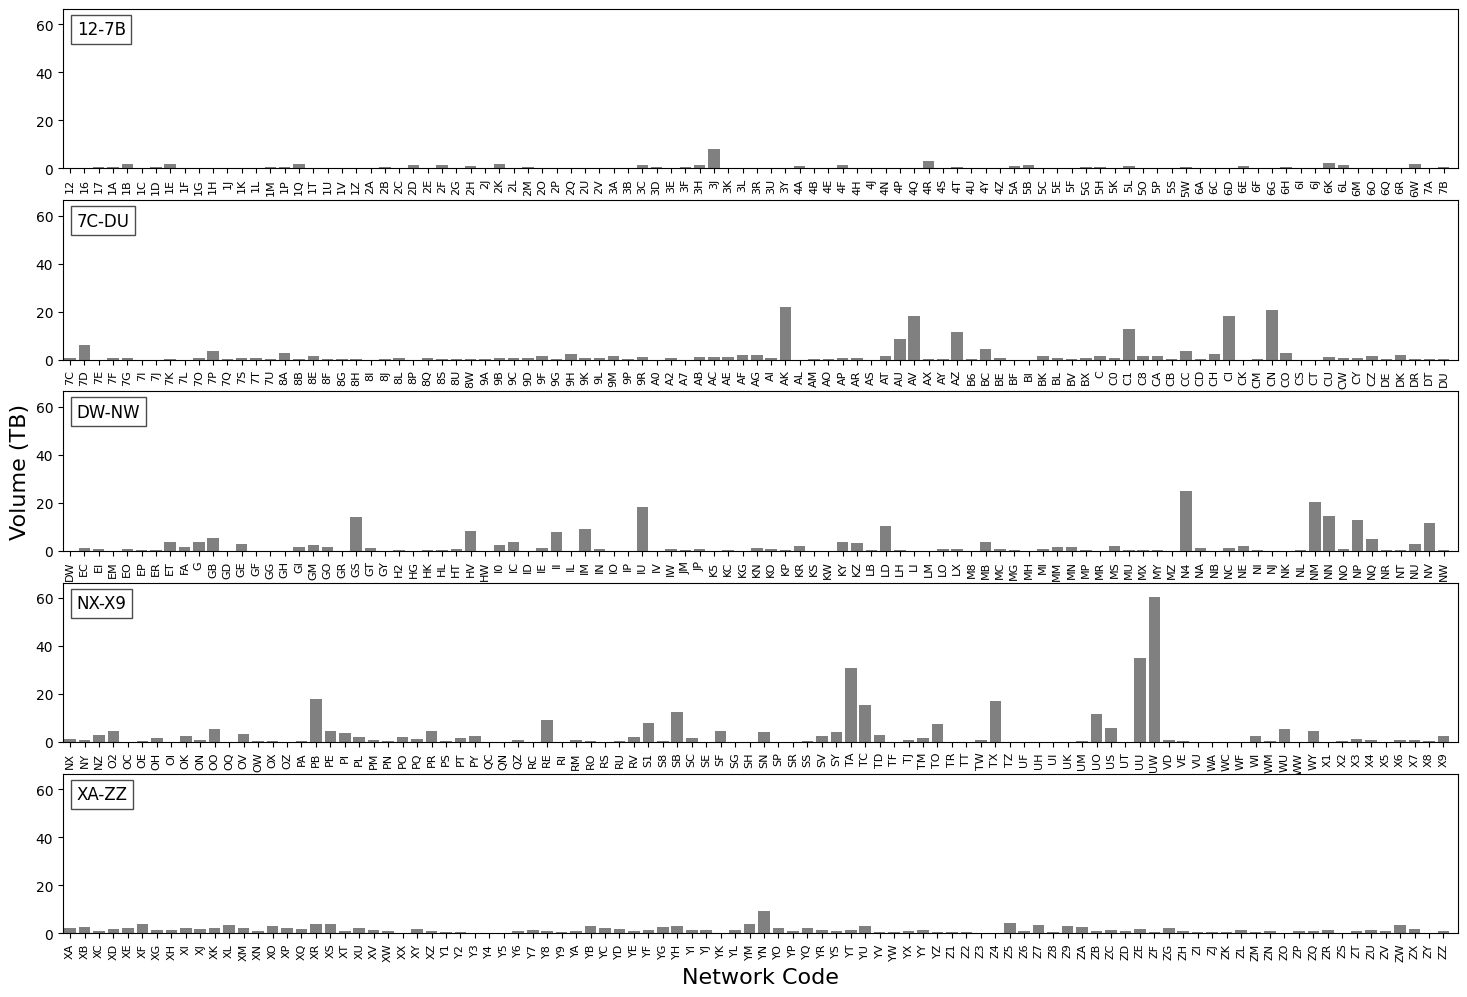

In [14]:
nsub = 5
ps = np.array_split(net_size_count, nsub)
pmax = max([i[1] for i in net_size_count]) * 1.1
plt.figure(figsize = (18, 12))
for p in range(nsub):
    plt.subplot(nsub, 1, p+1)
    plt.bar(np.arange(len([i[1] for i in ps[p]])), 
        [float(i[1]) for i in ps[p]], color='gray')
    plt.xticks(np.arange(len([i[1] for i in ps[p]])), [i[0] for i in ps[p]], rotation = 90, fontsize= 8);
    plt.xlim([-0.5, len(ps[p])])
    plt.ylim([0, pmax])
    plt.text(.01, .84, f"{ps[p][0][0]}-{ps[p][-1][0]}", transform=plt.gca().transAxes, 
             bbox=dict(facecolor='white', alpha=0.7), fontsize=12)
    if p == 2:
        plt.ylabel("Volume (TB)", fontsize = 16)
plt.xlabel("Network Code", fontsize = 16)